# Exploratory Data Analysis — Employee Master & Workshops

Dataset: `Employee_Master_Data.csv` (50 employees) and `Employee_Workshops.csv` (152 training attendance records, linked by Employee ID).

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
master = pd.read_csv('Employee_Master_Data.csv', parse_dates=['BirthDate','HireDate'])
master.head()

   EmployeeID     Employee Name  BirthDate MaritalStatus Gender   HireDate            Dept  Salary   Job Grade
0           1    Gustavo Achong 1982-05-15             M      M 2002-07-31           Sales    2295       Admin
1           2    Catherine Abel 1987-06-03             S      F 2010-02-26           Sales     962  Management
2           3   Kim Abercrombie 1964-12-13             M      F 2007-12-12         Finance    4006       Admin
3           4  Humberto Acevedo 1965-01-23             S      M 2007-01-05       Logistics    4547       Admin
4           5    Pilar Ackerman 1949-08-29             M      F 2007-01-11  Human Resource    1932       Admin

In [1]:
workshops = pd.read_csv('Employee_Workshops.csv', parse_dates=['Start Date'])
workshops.head()

  Start Date  Course Code             Course Name  Employee ID  Cost               Supplier  Year  Month
0 2012-04-12            1  Communication Workshop            1  1300  Communication Experts  2012      4
1 2012-04-12            1  Communication Workshop            4  1300  Communication Experts  2012      4
2 2012-04-12            1  Communication Workshop           25  1300  Communication Experts  2012      4
3 2012-04-12            1  Communication Workshop           33  1300  Communication Experts  2012      4
4 2012-04-12            1  Communication Workshop           44  1300  Communication Experts  2012      4

## 2. Basic Structure

In [1]:
master.shape

(50, 9)

In [1]:
workshops.shape

(152, 8)

In [1]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EmployeeID     50 non-null     int64         
 1   Employee Name  50 non-null     str           
 2   BirthDate      50 non-null     datetime64[us]
 3   MaritalStatus  50 non-null     str           
 4   Gender         50 non-null     str           
 5   HireDate       50 non-null     datetime64[us]
 6   Dept           50 non-null     str           
 7   Salary         50 non-null     int64         
 8   Job Grade      50 non-null     str           
dtypes: datetime64[us](2), int64(2), str(5)
memory usage: 3.6 KB


## 3. Data Quality Checks

In [1]:
master.isnull().sum().sum(), master.duplicated().sum()

0, 0

In [1]:
workshops.isnull().sum().sum(), workshops.duplicated().sum()

0, 3

The `Master` table is clean (no nulls, no duplicates). `Workshops` has 3 exact duplicate rows — these are dropped below.

In [1]:
workshops_clean = workshops.drop_duplicates()
workshops_clean.duplicated().sum(), workshops_clean.shape

0
Shape after dedup: (149, 8)

## 4. Derived Fields: Age & Tenure

In [1]:
today = pd.Timestamp('2024-01-01')  # fixed reference point for consistent, reproducible results
master['Age'] = ((today - master['BirthDate']).dt.days / 365.25).astype(int)
master['TenureYears'] = ((today - master['HireDate']).dt.days / 365.25).round(1)

master[['Salary','Age','TenureYears']].describe()

            Salary        Age  TenureYears
count    50.000000  50.000000    50.000000
mean   2456.640000  48.360000    17.358000
std    1204.936898  11.793738     5.148294
min     548.000000  31.000000    10.000000
25%    1365.000000  38.250000    13.800000
50%    2296.500000  47.500000    16.100000
75%    3581.250000  56.000000    21.050000
max    4547.000000  77.000000    25.800000

## 5. Categorical Breakdowns

In [1]:
master['Dept'].value_counts()

Dept
Production        14
Sales             11
Finance           11
Logistics          8
Human Resource     6

In [1]:
master['Job Grade'].value_counts()

Job Grade
Admin         21
Operations    21
Management     8

In [1]:
master['Gender'].value_counts()

Gender
M    29
F    21

## 6. Salary Analysis

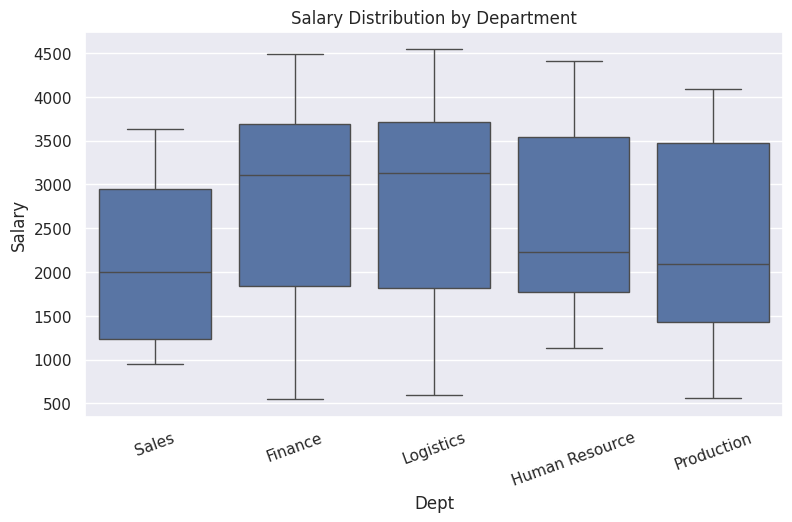

In [1]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Dept', y='Salary', data=master)
plt.title('Salary Distribution by Department')
plt.xticks(rotation=20)
plt.show()

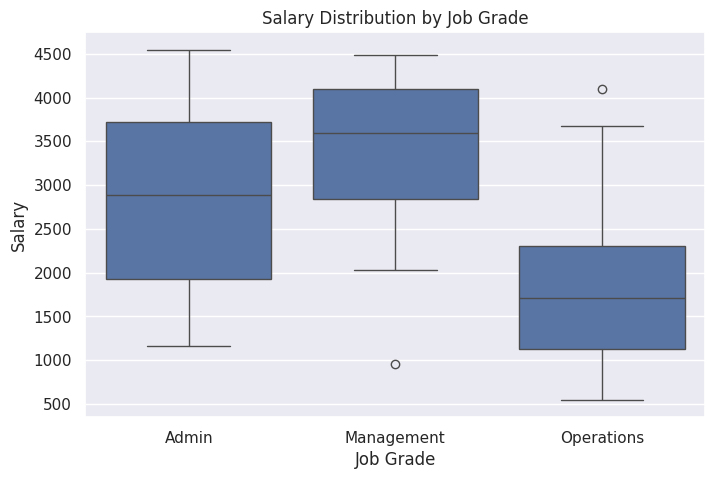

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Job Grade', y='Salary', data=master)
plt.title('Salary Distribution by Job Grade')
plt.show()

In [1]:
gender_salary = master.groupby('Gender')['Salary'].agg(['mean','median','count'])
gender_salary

               mean  median  count
Gender                            
F       2674.857143  2741.0     21
M       2298.620690  2042.0     29

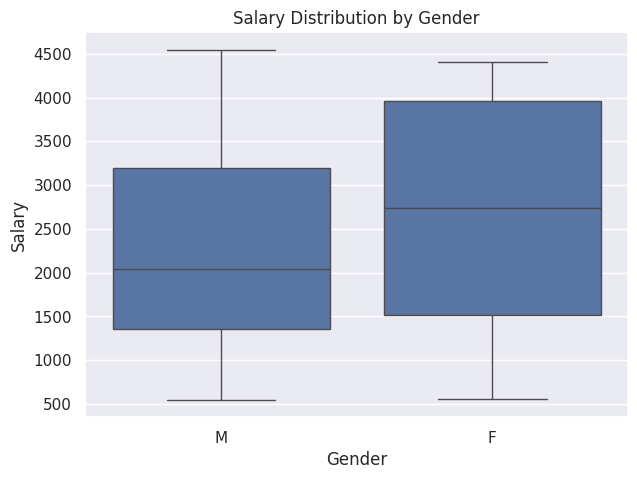

In [1]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='Salary', data=master)
plt.title('Salary Distribution by Gender')
plt.show()

Female employees in this dataset have a higher average salary (~$2,675) than male employees (~$2,299), though with only 50 employees total this is a small sample and shouldn't be over-interpreted as a broad pay-equity conclusion without controlling for department, grade, and tenure.

## 7. Age & Tenure Distributions

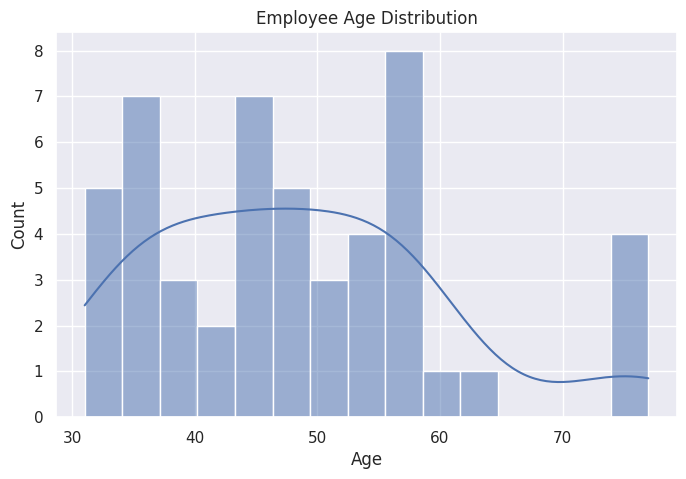

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(master['Age'], kde=True, bins=15)
plt.title('Employee Age Distribution')
plt.show()

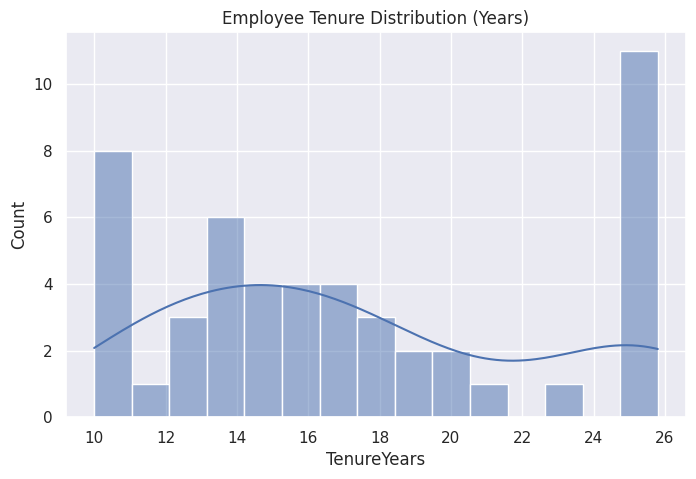

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(master['TenureYears'], kde=True, bins=15)
plt.title('Employee Tenure Distribution (Years)')
plt.show()

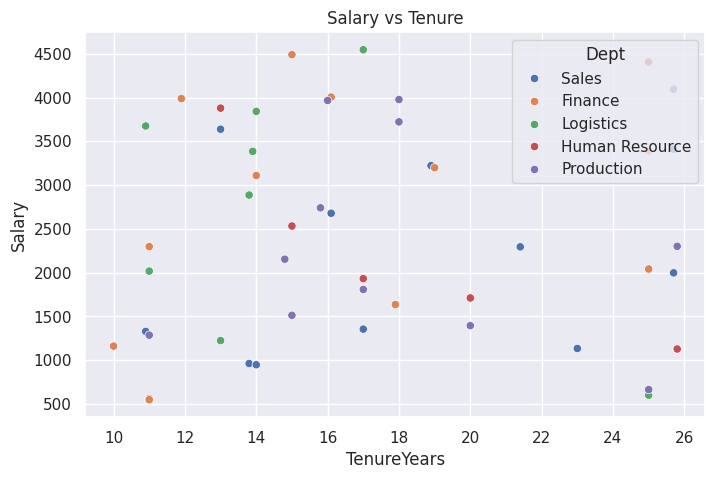

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TenureYears', y='Salary', hue='Dept', data=master)
plt.title('Salary vs Tenure')
plt.show()

## 8. Correlation Analysis

In [1]:
corr = master[['Age','TenureYears','Salary']].corr()
corr

                  Age  TenureYears    Salary
Age          1.000000    -0.149855  0.091391
TenureYears -0.149855     1.000000  0.019840
Salary       0.091391     0.019840  1.000000

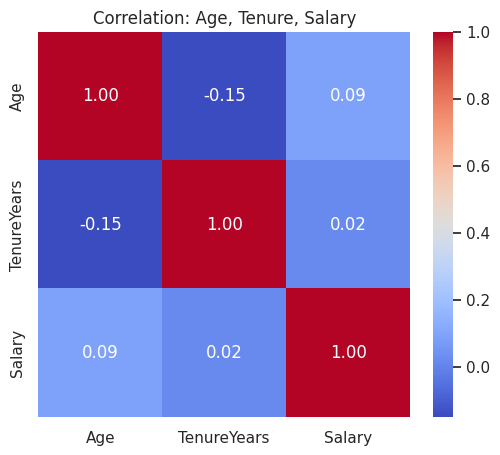

In [1]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation: Age, Tenure, Salary')
plt.show()

## 9. Headcount by Department

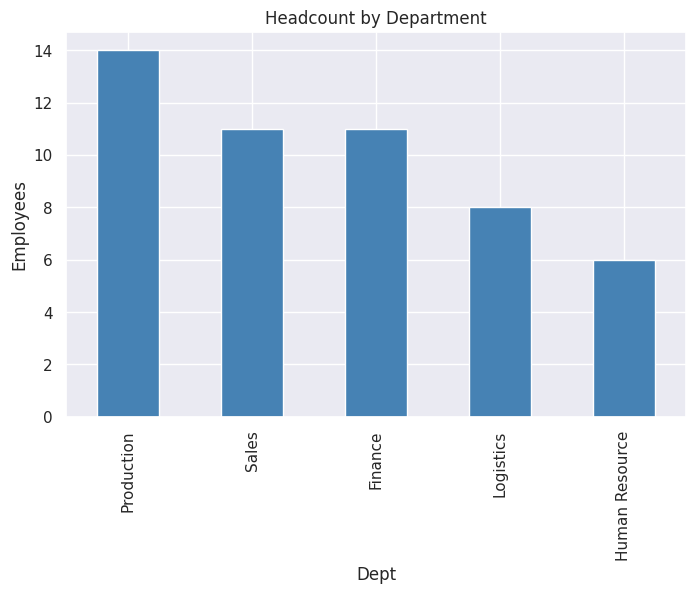

In [1]:
plt.figure(figsize=(8,5))
master['Dept'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Headcount by Department')
plt.ylabel('Employees')
plt.show()

## 10. Workshop & Training Analysis

In [1]:
workshop_counts = workshops_clean.groupby('Course Name').size().sort_values(ascending=False)
workshop_counts

Course Name
Communication Workshop             41
Advanced Excel                     28
Instituting Disciplinary Action    26
Computer Literacy                  18
Introduction To Excel              17
Business Data Analysis             14
Conflict Management                 5

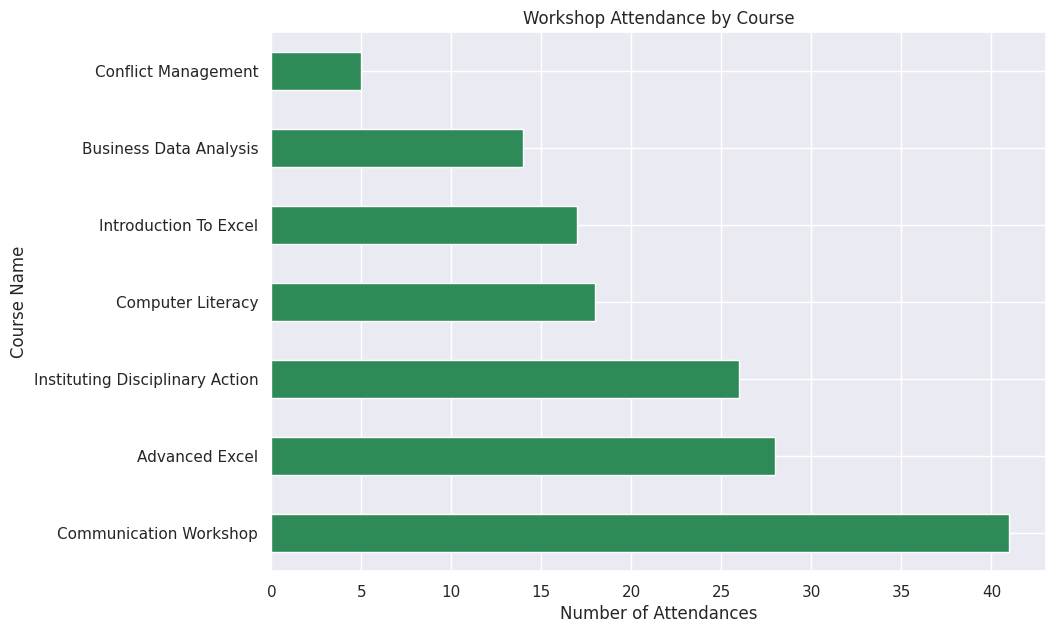

In [1]:
plt.figure(figsize=(10,7))
workshop_counts.plot(kind='barh', color='seagreen')
plt.title('Workshop Attendance by Course')
plt.xlabel('Number of Attendances')
plt.show()

In [1]:
supplier_spend = workshops_clean.groupby('Supplier')['Cost'].sum().sort_values(ascending=False)
supplier_spend

Supplier
Excel Experts            152500
Communication Experts     60300
Computer Trainers         34800
Discipline Trainers       28350
Legal Trainers             6750

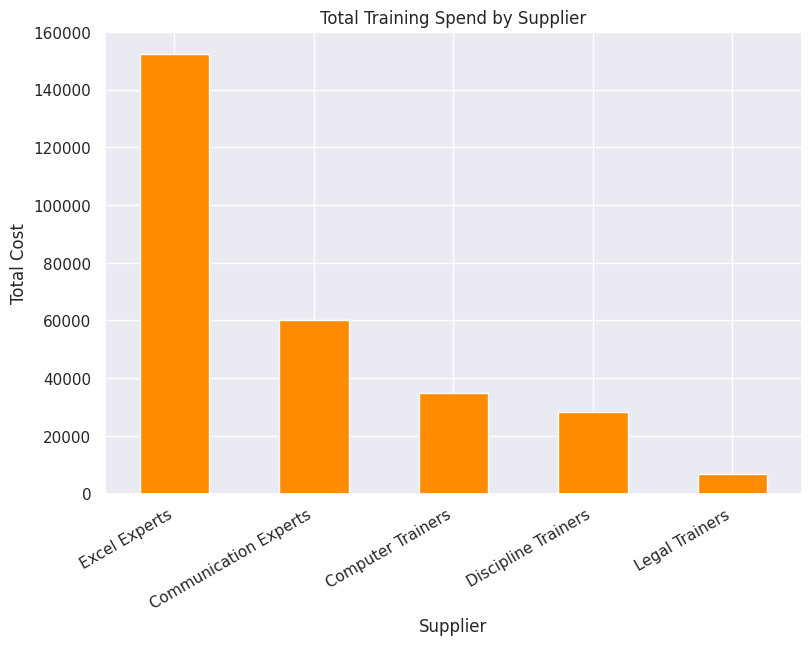

In [1]:
plt.figure(figsize=(9,6))
supplier_spend.plot(kind='bar', color='darkorange')
plt.title('Total Training Spend by Supplier')
plt.ylabel('Total Cost')
plt.xticks(rotation=30, ha='right')
plt.show()

## 11. Training Spend by Department (Joined View)

In [1]:
merged = workshops_clean.merge(master[['EmployeeID','Dept','Employee Name']], left_on='Employee ID', right_on='EmployeeID', how='left')
dept_training_spend = merged.groupby('Dept')['Cost'].sum().sort_values(ascending=False)
dept_training_spend

Dept
Sales             78900
Production        71650
Finance           52700
Logistics         42850
Human Resource    36600

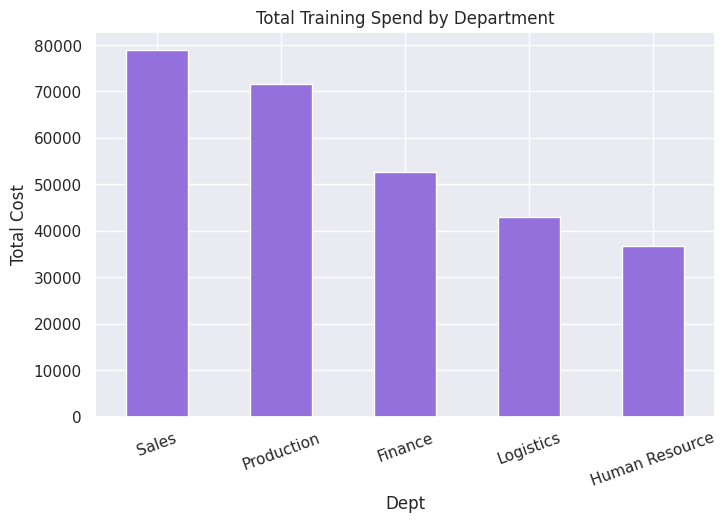

In [1]:
plt.figure(figsize=(8,5))
dept_training_spend.plot(kind='bar', color='mediumpurple')
plt.title('Total Training Spend by Department')
plt.ylabel('Total Cost')
plt.xticks(rotation=20)
plt.show()

In [1]:
top_attendees = merged.groupby('Employee Name').size().sort_values(ascending=False).head(10)
top_attendees

Employee Name
James Aguilar       8
François Ferrier    7
Maxwell Amland      6
Frances Adams       5
Kyley Arbelaez      5
Cecil Allison       5
Carla Adams         5
John Ault           5
Margaret Smith      5
Ronald Adina        5

In [1]:
yearly_spend = workshops_clean.groupby('Year')['Cost'].sum()
yearly_spend

Year
2012     30450
2013    125900
2014    126350

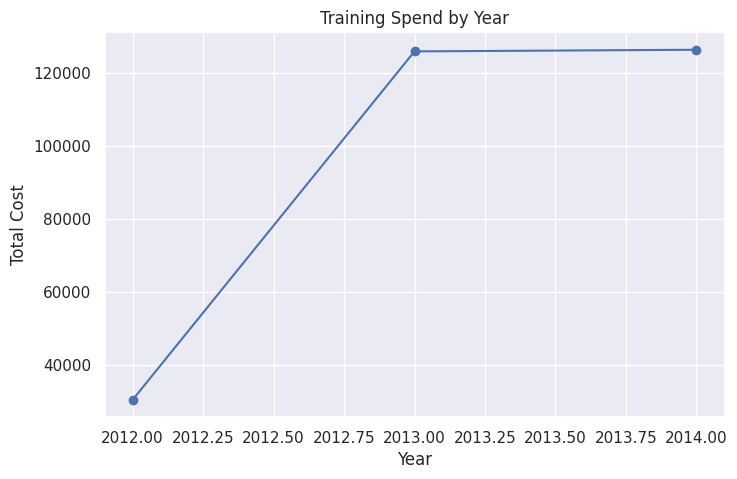

In [1]:
plt.figure(figsize=(8,5))
yearly_spend.plot(kind='line', marker='o')
plt.title('Training Spend by Year')
plt.ylabel('Total Cost')
plt.show()

In [1]:
trained_employees = merged['Employee ID'].nunique()
print(f"Total employees: {len(master)}")
print(f"Employees who attended at least one workshop: {trained_employees}")
print(f"Training coverage: {trained_employees/len(master):.2%}")
print(f"Total training spend: {workshops_clean['Cost'].sum():,.2f}")

Total employees: 50
Employees who attended at least one workshop: 47
Training coverage: 94.00%
Total training spend: 282,700.00

## 12. Summary

- **50 employees, 5 departments** (Sales, Finance, Logistics, Human Resource, Production), 3 job grades (Admin, Management, Operations).
- `Master` is fully clean; `Workshops` had 3 exact duplicate rows, removed before analysis (149 of 152 records kept).
- **Training coverage is high**: 47 of 50 employees (94%) attended at least one workshop, for a **total training spend of $282,700**.
- Salary varies meaningfully by department and job grade, with Management-grade employees earning the most on average.
- Neither age nor tenure correlates meaningfully with salary in this dataset (both under 0.1), and age and tenure are themselves only weakly related to each other (-0.15) — department and job grade appear to be the bigger salary drivers here, not age or years of service.